# Analiza masinskih ucenja

U Ovoj svesci cemo uporediti nekoliko algoritama za masinsko ucenje i ustanovicemo koje nam daje tacnije rezultate

## Korask 1: ucitavanje dataseta

Koristimo *pandas* kako bi ucitali dataset.

Prikazujemo prvih 5 redova kako bi se upoznali sa podacima.

In [55]:
import pandas as pd

df = pd.read_csv("messages.csv")

df.head()

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Korak 2: Prikaz specijalnih kolona

Prikazujemo broj nedostajucih vrednosti po kolonama i sve jedinstvene vrednosti koje postoje u koloni *category*.

In [56]:
print("Nedostajuce vrednosti po kolonama:\n", df.isna().sum()) 
print("\nJedinstvene vrednosti po kolonama:")
print(df['category'].unique())

Nedostajuce vrednosti po kolonama:
 category    111
message      55
dtype: int64

Jedinstvene vrednosti po kolonama:
<StringArray>
['ham', 'spam', 'not spam', nan]
Length: 4, dtype: str


## Korak 3: Standardizacija

Cistitmo i pripremamo podatake tako sto cemo:
- Ukloniti sve redove u koloni *category* i *message* koje sadrze NaN vrednosti,
- Pretvaramo sve vrednosti u koloni *category* u mala slova,
- Standardizujemo vrednosti u koloni *category*, tako da unutar nje na kraju postoje samo vrednosti *spam* i *ham*.

In [57]:
df = df.dropna()

df['category'] = df['category'].str.strip().str.lower()

df = df[df['category'].isin(['spam', 'ham'])]

## Korak 4: Podela vrednosti

U ovom koraku delimo podatke na X (ulazne poruke) i y (ciljne vrendnosti).

Iz biblioteke **sklearn.model_selection** importujemo **train_test_split** kako bi mogli da treniramo podatke.

Dodajemo parametre:
- *test_size=* kako bi podelili koliko podataka ide na testiranje a koliko podataka se koristi za treniranje,
- *random_state=* kako bi dobili uvek isti rezultat, jer se koristi isti seed za generator slucajnih brojeva,
- *stratify=* obezbedjuje da raspodela klasa bude ista i u trenig i u test setu, kao sto je bila u originalnom skupu.

In [58]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Korak 5: Vektorizacija teksta

Pretvaramo tekstualne poruke u numericki oblik koji algoritmi mogu da razumeju.

Iz biblioteke **sklearn.feature_extraction.text** uvozimo **TfidfVectorizer** kako bi pretvorili tekstualne poruke u numericki oblik,

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## Korak 6: Treniranje vise modela i evaluacija porformansi

Importovacemo nekoliko modela pomocu kojih cemo proveravati nas dataset a ujedno i pronaci koji algoritam nam daje najtacnije rezultate.

Koristicemo:
- **MultinomialNB** ,
- **DecisionTreeClassifier**,
- **LogisticRegression** dodajemo parametar *max_iter=1000* koje nam postavlja gornju granicu koliko puta algoritam sme da ponovi neki proces (Ako se resenje pronadje ranije, algoritam se zaustavlja pre nego sto dodje do 1000 iteracija),
- **LinearSVC**.

Pravimo recnik kako bi mogli kasnije da ih lakse klasifikujemo.

Iz biblioteke **sklearn.metrics** uvozimo **classification_report** i **accuracy_score** kako bismo dobili potrebne matrice i mogli da citamo i analiziramo dobijene podatke.

In [60]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": LinearSVC()
}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    print(f"\n{name} - Classification Report:")
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Logistic Regression - Classification Report:

Accuracy: 0.9671497584541063
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       890
        spam       0.97      0.79      0.87       145

    accuracy                           0.97      1035
   macro avg       0.97      0.89      0.93      1035
weighted avg       0.97      0.97      0.97      1035


Naive Bayes - Classification Report:

Accuracy: 0.9594202898550724
              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       890
        spam       1.00      0.71      0.83       145

    accuracy                           0.96      1035
   macro avg       0.98      0.86      0.90      1035
weighted avg       0.96      0.96      0.96      1035


Decision Tree - Classification Report:

Accuracy: 0.9690821256038648
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       890
        spam       0.92

## Korak 7: Matrice zabune

U ovom delu analiziramo performanse razlicitih algoritama masinskog ucenja konkretno **matricu zabune** koja nam prikazuje broj tacno i pogresno klasifikovanih instanci po klasama.

Importujemo iz biblioteke **sklearn.metrics** **confusion_matrix** kako bi dobili matrice zabune za vec pomenute algoritme.

Dodajemo takodje **seaborn** i **matplotlib.pyplot** kako bismo mogli da ih vizualizujemo i lakse citamo.

Logistic Regression - Confusion Matrix:
[[886   4]
 [ 30 115]]


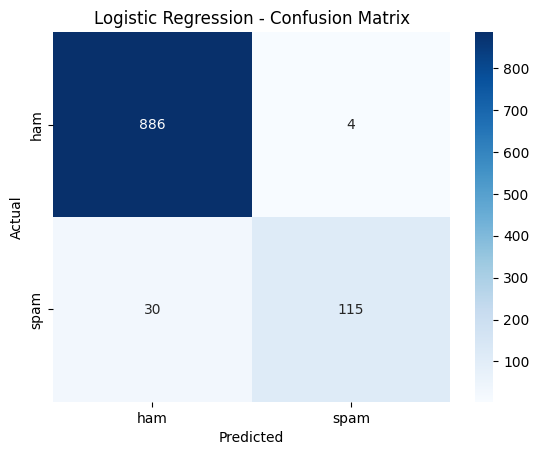

Naive Bayes - Confusion Matrix:
[[890   0]
 [ 42 103]]


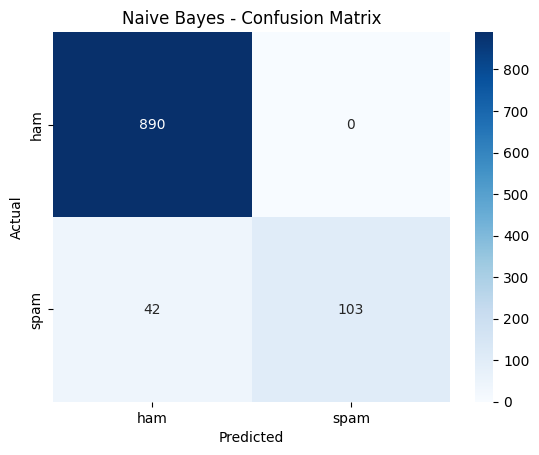

Decision Tree - Confusion Matrix:
[[878  12]
 [ 20 125]]


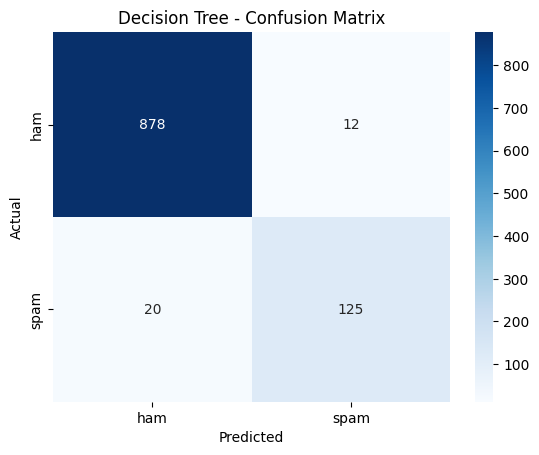

Support Vector Machine - Confusion Matrix:
[[887   3]
 [ 12 133]]


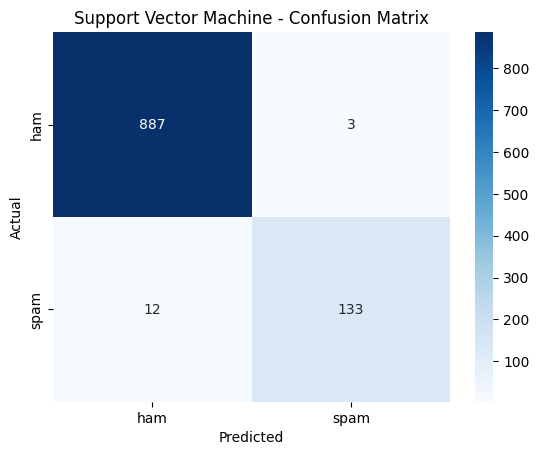

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    cm = confusion_matrix(y_test, y_pred)
    print(f"{name} - Confusion Matrix:\n{cm}")
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['ham','spam'], yticklabels=['ham','spam'])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Zakljucak

Najbolje ukupne rezultate pokazali su Logisticka regresija i SVM, sa oko 97–99% tacnosti.
Naive Bayes daje dobre rezultate, ali nešto losije u balansu odziva i preciznosti.
Decision Tree ima najnize metrike, ali i dalje vrlo dobre performanse.
Svi modeli rade solidno, ali Logisticka regresija i SVM pruzaju najbolji balans izmeddju tacnosti i F1 mere.

### Koj algoritam se najbolje pokazao, a koji najlosije

- Najbolje: **Support Vector Machine**
- Najlosije: **Naive Bayes** (jer ima najnizi recall za spam, iako je precizan)

### Na osnovu cega je utvrdjeno

- **Ukupna tacnost (accuracy)** – SVM ima najvisu tacnost (99%), dok Naive Bayes ima najnizu (96%).
- **F1 mera** – SVM ima najvisu F1 vrednost (0.95 za spam, 0.99 ukupno), dok Naive Bayes ima najnizu (0.83 za spam).
- **Balans izmedju preciznosti i odziva** – SVM najbolje balansira oba parametra, dok Naive Bayes ima ekstremno visoku preciznost, ali nizak recall za spam.